# Sweep plots: cheating vs original

Loads `main_test_parallel_cheating_sweep.json` (cheating runner output) plus `../main_test_parallel_sweep.json` (original SeQUeNCe runner output) and renders both curves side-by-side:

1. **Left:** `F_corrected` vs `two_qubit_gate_fidelity` (linear)
2. **Right:** `1 - F_corrected` vs `1 - two_qubit_gate_fidelity` (log-log infidelity)

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

CHEATING_PATH = Path('main_test_parallel_cheating_sweep.json')
ORIGINAL_PATH = Path('..') / 'main_test_parallel_sweep.json'

with CHEATING_PATH.open('r', encoding='utf-8') as f:
    cheating = json.load(f)
with ORIGINAL_PATH.open('r', encoding='utf-8') as f:
    original = json.load(f)

cheat_fid = np.asarray(cheating['two_qubit_gate_fidelity'], dtype=float)
cheat_F = np.asarray(cheating['F_corrected'], dtype=float)
cheat_one_minus = np.asarray(cheating['one_minus_F_corrected'], dtype=float)
cheat_infid = 1.0 - cheat_fid

orig_fid = np.asarray(original['two_qubit_gate_fidelity'], dtype=float)
orig_F = np.asarray(original['F_corrected'], dtype=float)
orig_one_minus = np.asarray(original['one_minus_F_corrected'], dtype=float)
orig_infid = 1.0 - orig_fid

print(f"cheating: {len(cheat_fid)} points, N = {cheating['num_logical_pairs_per_fidelity']} pairs/fidelity, base_seed = {cheating['base_seed']}")
print(f"original: {len(orig_fid)} points, N = {original['num_logical_pairs_per_fidelity']} pairs/fidelity")

cheating: 18 points, N = 100000 pairs/fidelity, base_seed = 3681542308
original: 10 points, N = 10000 pairs/fidelity


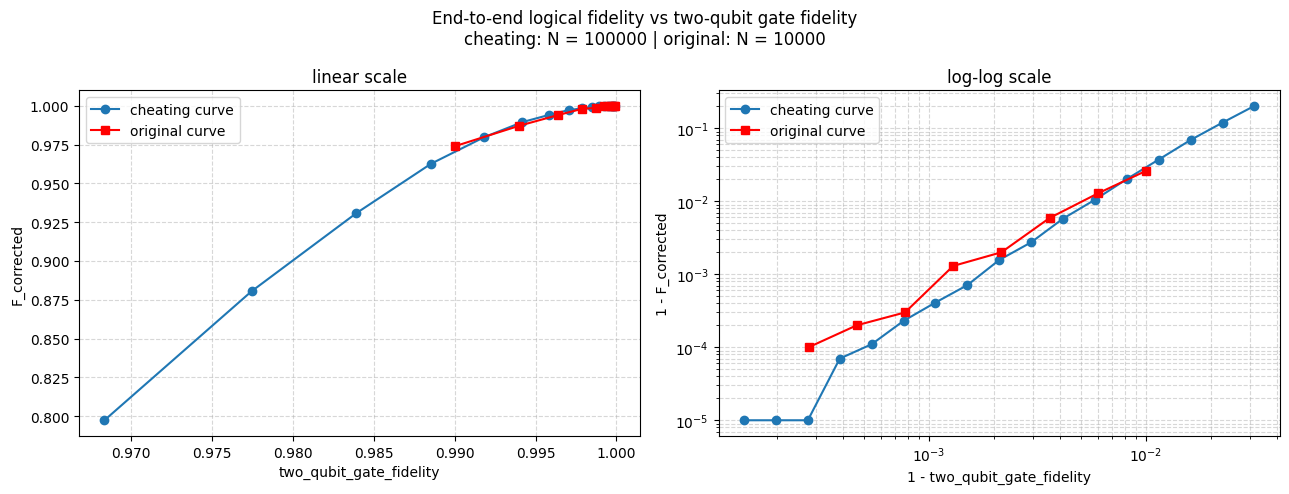

In [2]:
fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(13, 5))

# Left: linear F_corrected vs gate fidelity.
ax_lin.plot(cheat_fid, cheat_F, marker='o', linestyle='-', label='cheating curve')
ax_lin.plot(orig_fid, orig_F, marker='s', linestyle='-', color='red', label='original curve')
ax_lin.set_xlabel('two_qubit_gate_fidelity')
ax_lin.set_ylabel('F_corrected')
ax_lin.set_title('linear scale')
ax_lin.grid(True, which='both', linestyle='--', alpha=0.5)
ax_lin.legend()

# Right: log-log infidelity (drop zeros so the line stays continuous on log axes).
cheat_mask = (cheat_one_minus > 0) & (cheat_infid > 0)
orig_mask = (orig_one_minus > 0) & (orig_infid > 0)
ax_log.loglog(cheat_infid[cheat_mask], cheat_one_minus[cheat_mask], marker='o', linestyle='-', label='cheating curve')
ax_log.loglog(orig_infid[orig_mask], orig_one_minus[orig_mask], marker='s', linestyle='-', color='red', label='original curve')
ax_log.set_xlabel('1 - two_qubit_gate_fidelity')
ax_log.set_ylabel('1 - F_corrected')
ax_log.set_title('log-log scale')
ax_log.grid(True, which='both', linestyle='--', alpha=0.5)
ax_log.legend()

fig.suptitle(
    f"End-to-end logical fidelity vs two-qubit gate fidelity\n"
    f"cheating: N = {cheating['num_logical_pairs_per_fidelity']} | original: N = {original['num_logical_pairs_per_fidelity']}"
)
fig.tight_layout()
plt.show()

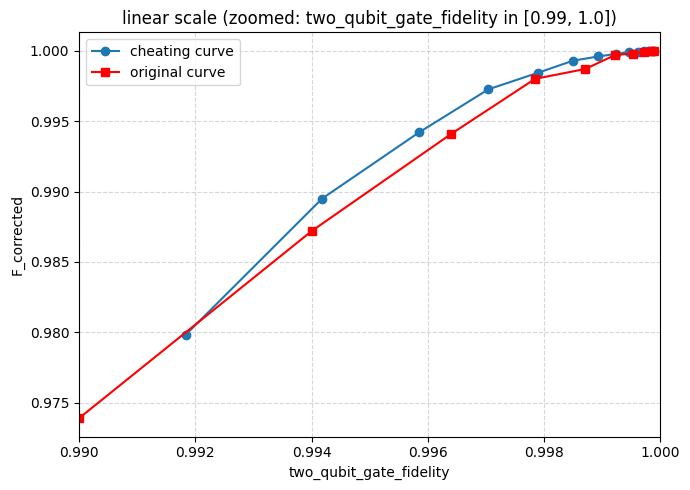

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))

# Same plot as the left subplot above, but restricted to two_qubit_gate_fidelity in [0.99, 1.0].
# Mask the data so the y-axis autoscale fits only the visible window.
xlim_lo, xlim_hi = 0.99, 1.0
cheat_zoom = (cheat_fid >= xlim_lo) & (cheat_fid <= xlim_hi)
orig_zoom = (orig_fid >= xlim_lo) & (orig_fid <= xlim_hi)

ax.plot(cheat_fid[cheat_zoom], cheat_F[cheat_zoom], marker='o', linestyle='-', label='cheating curve')
ax.plot(orig_fid[orig_zoom], orig_F[orig_zoom], marker='s', linestyle='-', color='red', label='original curve')
ax.set_xlim(xlim_lo, xlim_hi)
ax.set_xlabel('two_qubit_gate_fidelity')
ax.set_ylabel('F_corrected')
ax.set_title('linear scale (zoomed: two_qubit_gate_fidelity in [0.99, 1.0])')
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.legend()
fig.tight_layout()
plt.show()


saved -> /Users/bikunli/Documents/python_files/QEC_teleportation_cnot/customized_Sequence/Quantum-Repeater-Encoding/cheating/sweep_first_plot.pdf


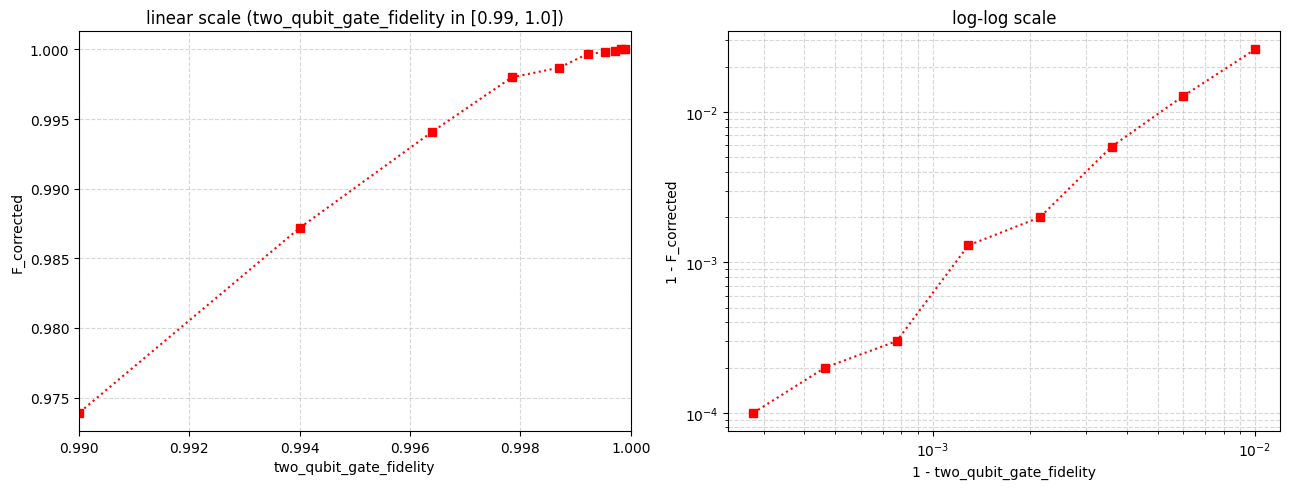

In [4]:
# Save side-by-side (linear + log-log) original-only figure as PDF in this folder.
# No legend; linear panel zoomed to two_qubit_gate_fidelity in [0.99, 1.0];
# data points connected with dotted lines; cropped tight.
fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(13, 5))

xlim_lo, xlim_hi = 0.99, 1.0
orig_zoom = (orig_fid >= xlim_lo) & (orig_fid <= xlim_hi)

ax_lin.plot(orig_fid[orig_zoom], orig_F[orig_zoom], marker='s', linestyle=':', color='red')
ax_lin.set_xlim(xlim_lo, xlim_hi)
ax_lin.set_xlabel('two_qubit_gate_fidelity')
ax_lin.set_ylabel('F_corrected')
ax_lin.set_title('linear scale (two_qubit_gate_fidelity in [0.99, 1.0])')
ax_lin.grid(True, which='both', linestyle='--', alpha=0.5)

orig_log_mask = (orig_one_minus > 0) & (orig_infid > 0)
ax_log.loglog(orig_infid[orig_log_mask], orig_one_minus[orig_log_mask], marker='s', linestyle=':', color='red')
ax_log.set_xlabel('1 - two_qubit_gate_fidelity')
ax_log.set_ylabel('1 - F_corrected')
ax_log.set_title('log-log scale')
ax_log.grid(True, which='both', linestyle='--', alpha=0.5)

fig.tight_layout()

pdf_path = Path('sweep_first_plot.pdf')
fig.savefig(pdf_path, bbox_inches='tight')
print(f'saved -> {pdf_path.resolve()}')
plt.show()
